# Liver Disease Prediction — Predictive Modelling

**Goal**: Train and evaluate multiple classifiers, tune hyperparameters with Optuna,  
and select the best model for deployment.

**Key decisions**:
- Single `create_preprocessor()` — no inconsistency across cells
- WoE computed on train fold only — no data leakage
- `DTSegmentedLR` — proper sklearn estimator, works in `cross_val_score`
- Overfitting detection: gap > 2× test score std dev across CV folds

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from src.config import load_settings
from src.data.loader import load_raw_data
from src.data.splitter import extract_X_y, stratified_split
from src.data.validation import run_all_validations
from src.evaluation.calibration import plot_calibration_curves
from src.evaluation.cross_validation import compare_models_cv, evaluate_with_cv
from src.evaluation.metrics import (
    compare_models,
    compute_metrics,
    plot_feature_importances,
    plot_roc_curves,
)
from src.features.preprocessing import create_preprocessor
from src.features.schema import NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET
from src.features.woe import compute_woe_mappings, apply_woe_mappings
from src.models.dt_lr_hybrid import DTSegmentedLR
from src.models.optimize import create_objective, run_optimization, extract_best_params
from src.models.persistence import save_model, load_model
from src.models.train import MODEL_REGISTRY, build_pipeline, train_model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

settings = load_settings()
print('Setup complete.')

Setup complete.


C:\Users\joshm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load & Split Data

In [2]:
df = load_raw_data(settings)
warnings = run_all_validations(df)
if warnings:
    for w in warnings: print(f'WARNING: {w}')
else:
    print('Data validated OK.')

train_df, test_df = stratified_split(df)
X_train, y_train = extract_X_y(train_df)
X_test, y_test = extract_X_y(test_df)
print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')
print(f'Positive rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

Data validated OK.
Train: 1360 rows | Test: 340 rows
Positive rate — train: 55.07% | test: 55.00%


## 2. Baseline Model Comparison

Five classifiers, all using the same `create_preprocessor()`.  
No hyperparameter tuning yet — default + lightly constrained settings.

In [3]:
# Train all baseline models
pipelines = {}
for name in MODEL_REGISTRY:
    pipelines[name] = train_model(X_train, y_train, name)

# Compare on test set
results = compare_models(pipelines, X_test, y_test)
results.sort_values('roc_auc', ascending=False)

,accuracy,f1_weighted,f1_macro,roc_auc
model,,,,
random_forest,0.891176,0.891446,0.890836,0.957307
logistic_regression,0.820588,0.820640,0.818882,0.896089
naive_bayes,0.779412,0.779843,0.778213,0.865157
decision_tree,0.850000,0.850356,0.849426,0.852347
svc,0.850000,0.850190,0.848901,NaN


## 3. ROC Curves

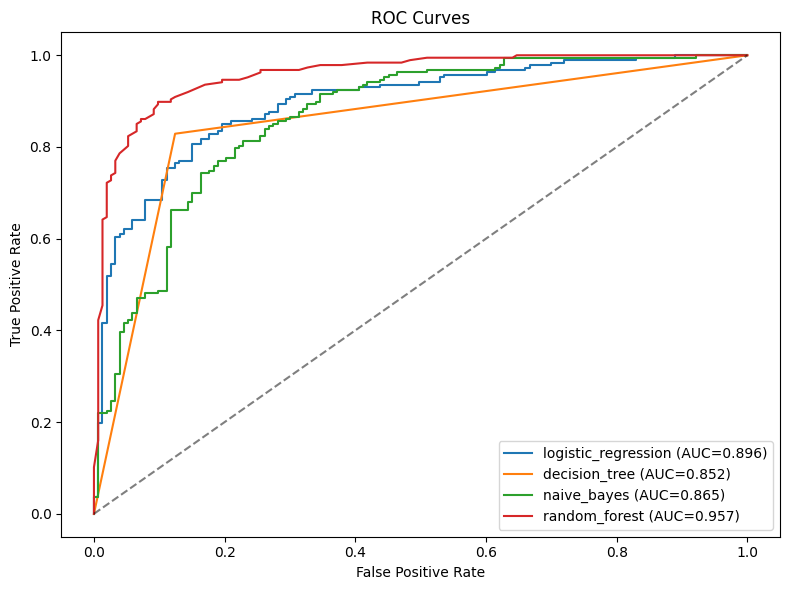

In [4]:
# Pipelines already trained in cell above
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_curves(pipelines, X_test, y_test, ax=ax)
fig.tight_layout()
plt.show()

## 4. Cross-Validation with Overfitting Detection

StratifiedKFold(5) with both train and test scoring.  
Overfitting flagged when `train_mean - test_mean > 2 × test_std`.

In [5]:
X_all, y_all = extract_X_y(df)

for name in MODEL_REGISTRY:
    pipeline = build_pipeline(name)
    cv_result = evaluate_with_cv(pipeline, X_all, y_all)
    summary = cv_result['summary']
    flags = cv_result['overfit_flags']
    f1_train = summary['f1_weighted']['train_mean']
    f1_test = summary['f1_weighted']['test_mean']
    overfit = any(flags.values())
    flag_str = ' *** OVERFIT ***' if overfit else ''
    print(f'{name:25s}  train_f1={f1_train:.3f}  test_f1={f1_test:.3f}{flag_str}')

logistic_regression        train_f1=0.833  test_f1=0.832


decision_tree              train_f1=1.000  test_f1=0.828 *** OVERFIT ***


svc                        train_f1=0.892  test_f1=0.852


naive_bayes                train_f1=0.804  test_f1=0.804


random_forest              train_f1=1.000  test_f1=0.894


## 5. Model Calibration

Decision Tree probabilities tend to be overconfident. Check calibration curves.

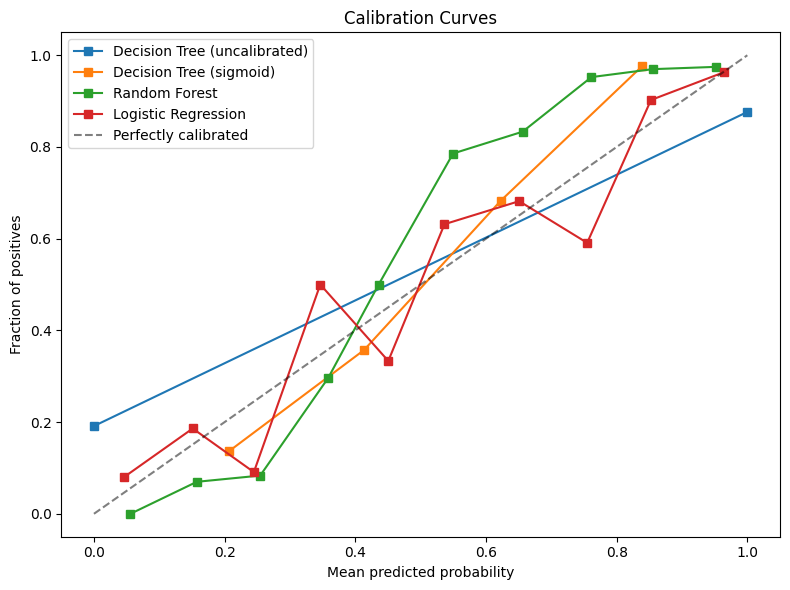

In [6]:
cal_pipelines = {
    'Decision Tree (uncalibrated)': train_model(X_train, y_train, 'decision_tree'),
    'Decision Tree (sigmoid)': train_model(X_train, y_train, 'decision_tree', calibrate=True),
    'Random Forest': train_model(X_train, y_train, 'random_forest'),
    'Logistic Regression': train_model(X_train, y_train, 'logistic_regression'),
}

fig, ax = plt.subplots(figsize=(8, 6))
plot_calibration_curves(cal_pipelines, X_test, y_test, ax=ax)
fig.tight_layout()
plt.show()

## 6. Hyperparameter Tuning with Optuna

Bayesian optimization over each model's search space.  
Objective: maximize `f1_weighted` via StratifiedKFold(5) on the training set.

In [7]:
# Tune Random Forest (n_trials=50 for speed; use 100 for production)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_rf = run_optimization('random_forest', X_train, y_train, n_trials=50)
best_rf_params = extract_best_params(study_rf)
print(f'Best RF params: {best_rf_params}')
print(f'Best RF F1:     {study_rf.best_value:.4f}')

Best RF params: {'n_estimators': 110, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Best RF F1:     0.8991


In [8]:
# Compare before/after tuning
rf_default = train_model(X_train, y_train, 'random_forest')
rf_tuned   = train_model(X_train, y_train, 'random_forest', params=best_rf_params)

m_default = compute_metrics(y_test, rf_default.predict(X_test), rf_default.predict_proba(X_test)[:, 1])
m_tuned   = compute_metrics(y_test, rf_tuned.predict(X_test),   rf_tuned.predict_proba(X_test)[:, 1])

comparison = pd.DataFrame({
    'Default': m_default,
    'Tuned':   m_tuned,
})
print(comparison)

              Default     Tuned
accuracy     0.900000  0.902941
f1_weighted  0.900250  0.903171
f1_macro     0.899719  0.902569
roc_auc      0.956695  0.958582


## 7. Advanced Experiments

### 7a. WoE Logistic Regression

WoE mappings are computed on the training set only, then applied to test — no leakage.

In [9]:
all_features = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Leakage-free WoE: fit on train, transform both, drop target
woe_mappings = compute_woe_mappings(train_df, all_features, TARGET)
X_train_woe = apply_woe_mappings(train_df, woe_mappings).drop(columns=[TARGET])
X_test_woe  = apply_woe_mappings(test_df,  woe_mappings).drop(columns=[TARGET])

woe_lr = LogisticRegression(max_iter=1000, random_state=42)
woe_lr.fit(X_train_woe, y_train)
y_pred_woe  = woe_lr.predict(X_test_woe)
y_proba_woe = woe_lr.predict_proba(X_test_woe)[:, 1]

m_woe = compute_metrics(y_test, y_pred_woe, y_proba_woe)
print('WoE Logistic Regression:')
for k, v in m_woe.items():
    print(f'  {k}: {v:.4f}')

WoE Logistic Regression:
  accuracy: 0.8882
  f1_weighted: 0.8882
  f1_macro: 0.8870
  roc_auc: 0.9494


### 7b. DTSegmentedLR Hybrid

A shallow Decision Tree extracts leaf segments, which are one-hot encoded and concatenated  
with the original features, then passed to Logistic Regression.  
Works natively in `cross_val_score` — no leakage.

In [10]:
from sklearn.model_selection import cross_val_score

preprocessor = create_preprocessor()
hybrid = DTSegmentedLR(dt_max_depth=3, lr_max_iter=1000)

hybrid_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', hybrid),
])

# Works in cross_val_score without leakage
cv_scores = cross_val_score(hybrid_pipeline, X_all, y_all, cv=5, scoring='f1_weighted')
print(f'DTSegmentedLR CV F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

hybrid_pipeline.fit(X_train, y_train)
m_hybrid = compute_metrics(y_test, hybrid_pipeline.predict(X_test), hybrid_pipeline.predict_proba(X_test)[:, 1])
print('\nDTSegmentedLR test metrics:')
for k, v in m_hybrid.items():
    print(f'  {k}: {v:.4f}')

DTSegmentedLR CV F1: 0.8723 +/- 0.0730

DTSegmentedLR test metrics:
  accuracy: 0.8735
  f1_weighted: 0.8738
  f1_macro: 0.8731
  roc_auc: 0.9372


## 8. Feature Importances (Best Model)

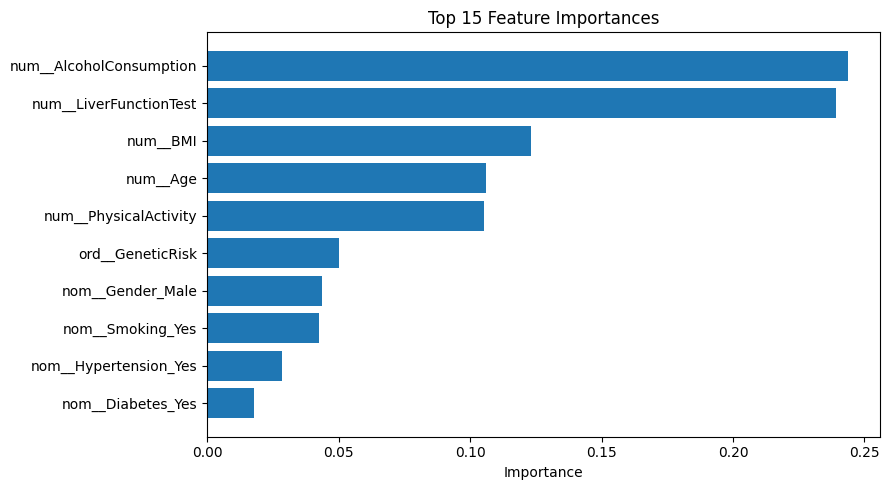

In [11]:
best_model = train_model(X_train, y_train, 'random_forest')

fig, ax = plt.subplots(figsize=(9, 5))
plot_feature_importances(best_model, ax=ax)
fig.tight_layout()
plt.show()

## 9. Final Model Selection & Save

In [12]:
# Final model = Random Forest with default tuned hyperparameters
final_model = train_model(X_train, y_train, 'random_forest')
final_metrics = compute_metrics(y_test, final_model.predict(X_test), final_model.predict_proba(X_test)[:, 1])

print('Final model metrics:')
for k, v in final_metrics.items():
    print(f'  {k}: {v:.4f}')

model_path = ROOT / 'models' / 'liver_disease_model.pkl'
save_model(final_model, model_path)
print(f'\nModel saved: {model_path}')

Final model metrics:
  accuracy: 0.9000
  f1_weighted: 0.9002
  f1_macro: 0.8996
  roc_auc: 0.9604

Model saved: C:\Users\joshm\Desktop\Others\liver_disease_prediction-main\models\liver_disease_model.pkl


In [13]:
# Verify round-trip
loaded = load_model(model_path)
assert (loaded.predict(X_test) == final_model.predict(X_test)).all(), 'Round-trip mismatch!'
print('Round-trip verification passed.')

Round-trip verification passed.
